# Best Basic + CutMix 모델 학습 및 내 강아지 예측

기존 7조건 비교에서 가장 높은 validation accuracy를 기록한
`basic + CutMix (alpha=0.2, p=0.5)` 조건을 다시 학습합니다.

- 모델: ImageNet pretrained ResNet-50
- 데이터: Stanford Dogs, 120 classes
- Basic augmentation: horizontal flip 50% + brightness jitter 0.1
- CutMix: `alpha=0.2`, batch 적용 확률 `p=0.5`
- Optimizer: SGD, learning rate 0.001
- Epoch: 20
- Seed: 42

매 epoch validation accuracy가 개선될 때 모델 가중치를 저장합니다.
학습이 끝나면 `../Ex02/images`의 사진을 best checkpoint로 예측합니다.

> 최초 실행은 **커널 재시작 후 위에서부터 순서대로 실행**하세요.


## 1. 환경과 실험 설정

기존 실험과 같은 seed와 학습 설정을 사용합니다. 결과는 기존 history 폴더와
분리된 `results_resnet50_best_basic_cutmix/`에 저장합니다.


In [1]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder


gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SEED = 42
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 0.001
MIX_ALPHA = 0.2
MIX_PROBABILITY = 0.5
NUM_WORKERS = 2
COOLDOWN_EVERY_EPOCHS = 5
COOLDOWN_SECONDS = 60

DATASET_DIR = Path("~/datasets/stanfordimagenetdogs/Images").expanduser()
IMAGE_DIR = Path("../Ex02/images")
RESULT_DIR = Path("results_resnet50_best_basic_cutmix")
CHECKPOINT_PATH = RESULT_DIR / "basic_cutmix_alpha0.2_p0.5_best.pt"
HISTORY_PATH = RESULT_DIR / "training_history.csv"
CONFIG_PATH = RESULT_DIR / "experiment_config.json"

# True로 바꾸면 기존 checkpoint가 있어도 처음부터 다시 학습합니다.
RETRAIN = False

RESULT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print(f"Device: {DEVICE}")
print(f"Dataset: {DATASET_DIR}")
print(f"Checkpoint: {CHECKPOINT_PATH.resolve()}")
print(f"Prediction images: {IMAGE_DIR.resolve()}")

Device: cuda
Dataset: /home/thkim0/datasets/stanfordimagenetdogs/Images
Checkpoint: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_best_basic_cutmix/basic_cutmix_alpha0.2_p0.5_best.pt
Prediction images: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex02/images


## 2. 데이터셋과 전처리

학습 데이터에는 Basic augmentation을 적용하고 validation 및 개인 사진에는
무작위 변환을 적용하지 않습니다. 추론 전처리가 validation 전처리와 같아야
학습 때와 입력 분포가 일치합니다.


In [2]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(f"데이터셋을 찾을 수 없습니다: {DATASET_DIR}")


def base_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5],
        ),
    ])


def basic_train_transform():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1),
        *base_transform().transforms,
    ])


full_dataset = ImageFolder(root=DATASET_DIR, transform=base_transform())
total_size = len(full_dataset)
train_size = int(0.583 * total_size)
val_size = total_size - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=split_generator,
)

class_names = full_dataset.classes
num_classes = len(class_names)


def indices_fingerprint(indices):
    index_array = np.asarray(list(indices), dtype=np.int64)
    return hashlib.sha256(index_array.tobytes()).hexdigest()


train_indices_sha256 = indices_fingerprint(train_subset.indices)
val_indices_sha256 = indices_fingerprint(val_subset.indices)


def make_loader(subset, transform, shuffle, seed=SEED):
    dataset_copy = copy.copy(subset.dataset)
    dataset_copy.transform = transform
    isolated_subset = Subset(dataset_copy, subset.indices)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        isolated_subset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


train_loader = make_loader(
    train_subset,
    transform=basic_train_transform(),
    shuffle=True,
)
val_loader = make_loader(
    val_subset,
    transform=base_transform(),
    shuffle=False,
)

sample_images, sample_labels = next(iter(train_loader))
assert sample_images.shape[1:] == (3, 224, 224)
assert sample_labels.dtype == torch.int64
assert min(full_dataset.targets) == 0
assert max(full_dataset.targets) == num_classes - 1

print(f"Classes: {num_classes}")
print(f"Train: {len(train_subset):,} | Validation: {len(val_subset):,}")
print(f"Batch shape: {sample_images.shape}")
print(f"Train indices SHA256: {train_indices_sha256}")
print(f"Validation indices SHA256: {val_indices_sha256}")
del sample_images, sample_labels

Classes: 120
Train: 11,998 | Validation: 8,582
Batch shape: torch.Size([16, 3, 224, 224])
Train indices SHA256: 77811abc456327ae4a99911df61fc926fd75541cedff92bdda2aef045a247492
Validation indices SHA256: c718b1070073d063d393f0d926409ad57a9e70b8534c5212d9a04bf3ca2c1ad1


## 3. 동일한 초기 모델과 CutMix

ResNet-50의 ImageNet pretrained convolution 가중치를 사용하고 마지막 FC layer만
120개 견종에 맞게 교체합니다.

CutMix는 다른 이미지의 임의 사각형 영역을 붙인 뒤, 실제 교체 면적으로 `lam`을
다시 계산합니다. 이 `lam`이 두 레이블의 Cross Entropy 비율이 됩니다.


In [3]:
set_seed()
base_model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)
base_model.fc = nn.Linear(base_model.fc.in_features, num_classes)
initial_model_state = copy.deepcopy(base_model.state_dict())
del base_model


def state_dict_fingerprint(state_dict):
    digest = hashlib.sha256()
    for name in sorted(state_dict):
        tensor = state_dict[name].detach().cpu().contiguous()
        digest.update(name.encode("utf-8"))
        digest.update(str(tensor.dtype).encode("utf-8"))
        digest.update(np.asarray(tensor.shape, dtype=np.int64).tobytes())
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()


initial_model_sha256 = state_dict_fingerprint(initial_model_state)


def create_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(initial_model_state)
    return model


def cutmix_batch(images, labels, alpha=MIX_ALPHA):
    lam = float(np.random.beta(alpha, alpha))
    indices = torch.randperm(images.size(0), device=images.device)

    height, width = images.shape[-2:]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_width = int(width * cut_ratio)
    cut_height = int(height * cut_ratio)

    center_x = torch.randint(width, (1,), device=images.device).item()
    center_y = torch.randint(height, (1,), device=images.device).item()

    x1 = max(center_x - cut_width // 2, 0)
    x2 = min(center_x + cut_width // 2, width)
    y1 = max(center_y - cut_height // 2, 0)
    y2 = min(center_y + cut_height // 2, height)

    mixed_images = images.clone()
    mixed_images[:, :, y1:y2, x1:x2] = images[
        indices, :, y1:y2, x1:x2
    ]

    replaced_ratio = ((x2 - x1) * (y2 - y1)) / (width * height)
    adjusted_lam = float(1.0 - replaced_ratio)
    assert 0.0 <= adjusted_lam <= 1.0

    return mixed_images, labels, labels[indices], adjusted_lam


test_images = torch.randn(4, 3, 224, 224)
test_labels = torch.arange(4)
mixed, labels_a, labels_b, test_lam = cutmix_batch(
    test_images,
    test_labels,
)
assert mixed.shape == test_images.shape
assert 0.0 <= test_lam <= 1.0
del test_images, test_labels, mixed, labels_a, labels_b

print(f"Initial model SHA256: {initial_model_sha256}")

Initial model SHA256: 0d7d077cf589e581e6b94d03e07a85d3911a46f683b9972684498327d005c960


## 4. Best checkpoint를 저장하는 학습 함수

`p=0.5`이므로 각 batch마다 50% 확률로 CutMix를 적용합니다.

- CutMix batch: 두 레이블의 CE를 실제 면적 비율로 가중합
- 원본 batch: `lam=1.0`이므로 일반 CE
- checkpoint 기준: 가장 높은 validation accuracy

checkpoint에는 모델 가중치뿐 아니라 클래스 순서, epoch, 성능, 데이터 분할 hash와
실험 설정을 함께 저장합니다.


In [4]:
def evaluate(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct += outputs.argmax(dim=1).eq(labels).sum().item()
            total += batch_size

    return running_loss / total, 100.0 * correct / total


def save_best_checkpoint(model, epoch, val_loss, val_accuracy):
    cpu_state_dict = {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }
    checkpoint = {
        "model_state_dict": cpu_state_dict,
        "architecture": "resnet50",
        "num_classes": num_classes,
        "class_names": class_names,
        "class_to_idx": full_dataset.class_to_idx,
        "epoch": epoch,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "seed": SEED,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "augmentation": "basic",
        "batch_mix": "cutmix",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "initial_model_sha256": initial_model_sha256,
        "train_indices_sha256": train_indices_sha256,
        "val_indices_sha256": val_indices_sha256,
        "input_size": [224, 224],
        "normalize_mean": [0.5, 0.5, 0.5],
        "normalize_std": [0.5, 0.5, 0.5],
    }
    torch.save(checkpoint, CHECKPOINT_PATH)


def train_and_save_best(model, train_loader, val_loader):
    set_seed(SEED)
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)
    best_val_accuracy = float("-inf")
    history_rows = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        weighted_correct = 0.0
        total = 0
        mixed_batches = 0
        total_batches = 0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            total_batches += 1

            if random.random() < MIX_PROBABILITY:
                mixed_batches += 1
                model_images, labels_a, labels_b, lam = cutmix_batch(
                    images,
                    labels,
                )
            else:
                model_images = images
                labels_a = labels_b = labels
                lam = 1.0

            optimizer.zero_grad()
            outputs = model(model_images)
            loss = (
                lam * criterion(outputs, labels_a)
                + (1.0 - lam) * criterion(outputs, labels_b)
            )
            loss.backward()
            optimizer.step()

            predicted = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            weighted_correct += (
                lam * predicted.eq(labels_a).sum().item()
                + (1.0 - lam) * predicted.eq(labels_b).sum().item()
            )
            total += batch_size

        train_loss = running_loss / total
        train_accuracy = 100.0 * weighted_correct / total
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)
        actual_mix_ratio = mixed_batches / total_batches

        history_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "mixed_batches": mixed_batches,
            "total_batches": total_batches,
            "actual_mix_ratio": actual_mix_ratio,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
        })
        pd.DataFrame(history_rows).to_csv(HISTORY_PATH, index=False)

        improved = val_accuracy > best_val_accuracy
        if improved:
            best_val_accuracy = val_accuracy
            save_best_checkpoint(
                model,
                epoch,
                val_loss,
                val_accuracy,
            )

        marker = " | BEST SAVED" if improved else ""
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.2f}% | "
            f"mixed {mixed_batches}/{total_batches} "
            f"({actual_mix_ratio:.3f}) | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_accuracy:.2f}%{marker}"
        )

        if epoch % COOLDOWN_EVERY_EPOCHS == 0 and epoch < EPOCHS:
            print(f"GPU 냉각을 위해 {COOLDOWN_SECONDS}초간 대기합니다.")
            time.sleep(COOLDOWN_SECONDS)

    return pd.DataFrame(history_rows)


experiment_config = {
    "experiment": "basic_cutmix_alpha0.2_p0.5_best_checkpoint",
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "SGD",
    "learning_rate": LEARNING_RATE,
    "augmentation": "basic",
    "batch_mix": "cutmix",
    "mix_alpha": MIX_ALPHA,
    "mix_probability": MIX_PROBABILITY,
    "checkpoint_metric": "val_accuracy",
}
CONFIG_PATH.write_text(
    json.dumps(experiment_config, indent=2),
    encoding="utf-8",
)

299

## 5. 학습 실행 또는 저장된 checkpoint 재사용

checkpoint가 없거나 `RETRAIN=True`이면 20 epoch를 학습합니다.
checkpoint가 이미 있으면 긴 학습을 반복하지 않고 저장된 모델을 사용합니다.


In [5]:
if RETRAIN or not CHECKPOINT_PATH.exists():
    model = create_model()
    assert state_dict_fingerprint(model.state_dict()) == initial_model_sha256
    history_df = train_and_save_best(model, train_loader, val_loader)

    model.to("cpu")
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    if not HISTORY_PATH.exists():
        raise FileNotFoundError(
            "checkpoint는 있지만 training history가 없습니다. "
            "RETRAIN=True로 다시 학습하세요."
        )
    history_df = pd.read_csv(HISTORY_PATH)
    print(f"저장된 checkpoint를 재사용합니다: {CHECKPOINT_PATH}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")

assert checkpoint["architecture"] == "resnet50"
assert checkpoint["num_classes"] == num_classes
assert checkpoint["class_names"] == class_names
assert checkpoint["train_indices_sha256"] == train_indices_sha256
assert checkpoint["val_indices_sha256"] == val_indices_sha256
assert checkpoint["augmentation"] == "basic"
assert checkpoint["batch_mix"] == "cutmix"
assert checkpoint["mix_alpha"] == MIX_ALPHA
assert checkpoint["mix_probability"] == MIX_PROBABILITY

print(
    f"Best checkpoint: epoch {checkpoint['epoch']} | "
    f"val loss {checkpoint['val_loss']:.4f} | "
    f"val acc {checkpoint['val_accuracy']:.4f}%"
)

/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 01/20 | train loss 4.5521 | train acc 10.53% | mixed 372/750 (0.496) | val loss 4.0340 | val acc 35.80% | BEST SAVED
Epoch 02/20 | train loss 3.8917 | train acc 35.68% | mixed 362/750 (0.483) | val loss 3.0155 | val acc 57.28% | BEST SAVED
Epoch 03/20 | train loss 3.2306 | train acc 48.81% | mixed 362/750 (0.483) | val loss 2.2131 | val acc 67.28% | BEST SAVED
Epoch 04/20 | train loss 2.7260 | train acc 55.79% | mixed 375/750 (0.500) | val loss 1.6359 | val acc 71.92% | BEST SAVED
Epoch 05/20 | train loss 2.3316 | train acc 60.00% | mixed 363/750 (0.484) | val loss 1.3376 | val acc 75.97% | BEST SAVED
GPU 냉각을 위해 60초간 대기합니다.
Epoch 06/20 | train loss 2.1470 | train acc 61.80% | mixed 390/750 (0.520) | val loss 1.1099 | val acc 78.06% | BEST SAVED
Epoch 07/20 | train loss 1.9289 | train acc 64.48% | mixed 370/750 (0.493) | val loss 0.9444 | val acc 80.06% | BEST SAVED
Epoch 08/20 | train loss 1.8298 | train acc 66.01% | mixed 379/750 (0.505) | val loss 0.8692 | val acc 80.81% | BEST

## 6. 학습곡선 확인

MixUp/CutMix의 train accuracy는 혼합된 두 레이블을 `lam`으로 가중한 값이므로,
일반적인 단일 레이블 accuracy와 의미가 다릅니다. 최종 모델 선택은 원본 validation
데이터의 accuracy를 사용합니다.


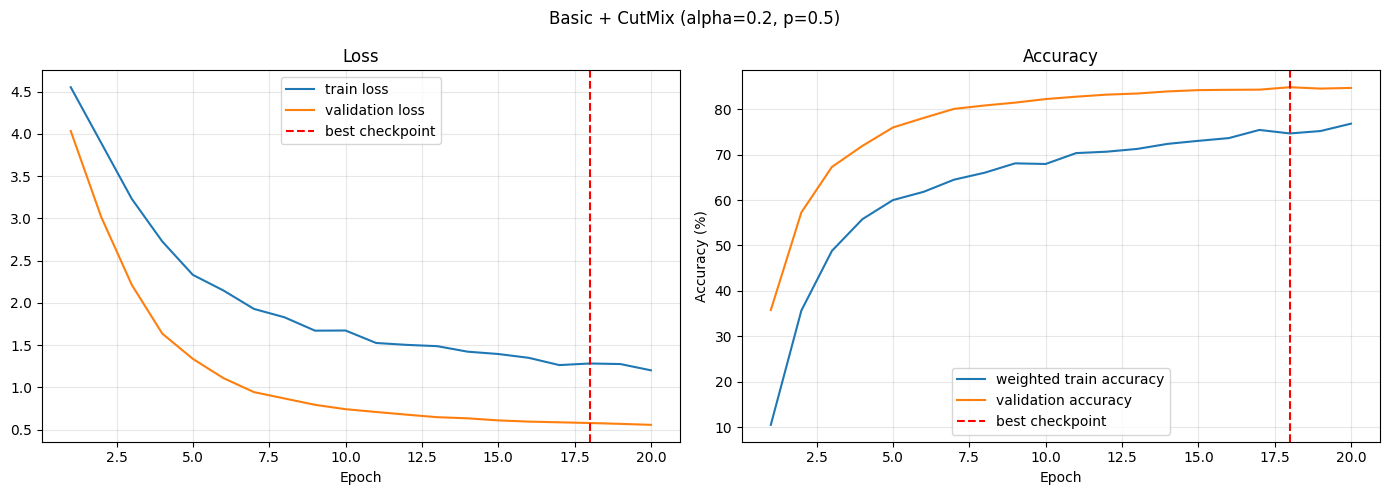

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="train loss",
)
axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="validation loss",
)
axes[0].axvline(
    checkpoint["epoch"],
    color="red",
    linestyle="--",
    label="best checkpoint",
)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="weighted train accuracy",
)
axes[1].plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="validation accuracy",
)
axes[1].axvline(
    checkpoint["epoch"],
    color="red",
    linestyle="--",
    label="best checkpoint",
)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle("Basic + CutMix (alpha=0.2, p=0.5)")
fig.tight_layout()
plt.show()

## 7. Best 모델 로드 및 개인 사진 전처리

추론에서는 CutMix나 Basic augmentation을 적용하지 않습니다. 사진을 validation과 같은
방식으로 전처리한 뒤 batch dimension을 포함한 `[N, 3, 224, 224]` tensor로 만듭니다.


In [7]:
best_model = models.resnet50(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, checkpoint["num_classes"])
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(DEVICE)
best_model.eval()

inference_transform = transforms.Compose([
    transforms.Resize(tuple(checkpoint["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=checkpoint["normalize_mean"],
        std=checkpoint["normalize_std"],
    ),
])

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"이미지 폴더를 찾을 수 없습니다: {IMAGE_DIR.resolve()}")

valid_extensions = {".jpg", ".jpeg", ".png", ".webp"}
image_paths = sorted(
    path
    for path in IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in valid_extensions
)

if not image_paths:
    raise FileNotFoundError(f"예측할 이미지를 찾지 못했습니다: {IMAGE_DIR.resolve()}")

original_images = []
input_tensors = []
for image_path in image_paths:
    image = Image.open(image_path).convert("RGB")
    input_tensor = inference_transform(image)
    assert input_tensor.shape == (3, 224, 224)

    original_images.append(image)
    input_tensors.append(input_tensor)

input_batch = torch.stack(input_tensors).to(DEVICE)
print(f"Images: {len(image_paths)}")
print(f"Input batch shape: {input_batch.shape}")
for image_path in image_paths:
    print(image_path)

Images: 5
Input batch shape: torch.Size([5, 3, 224, 224])
../Ex02/images/26444.jpg
../Ex02/images/47643(1).jpg
../Ex02/images/84349.jpg
../Ex02/images/91092.jpg
../Ex02/images/dog2.jpg


## 8. Top-3 견종 예측

`softmax`로 120개 클래스의 상대적인 확률을 계산하고 각 사진의 Top-3를 표시합니다.
개인 사진이 학습 데이터와 배경·촬영 각도·품종 구성이 다르면 confidence가 낮거나
비슷한 외형의 다른 견종으로 예측될 수 있습니다.


,file,top1_breed,top1_probability,top2_breed,top2_probability,top3_breed,top3_probability
0,26444.jpg,Lhasa,31.68,Shih-Tzu,20.00,Yorkshire terrier,10.11
1,47643(1).jpg,Shih-Tzu,20.12,briard,15.87,Tibetan terrier,10.96
2,84349.jpg,silky terrier,46.17,Australian terrier,14.50,Yorkshire terrier,12.98
3,91092.jpg,Yorkshire terrier,42.02,silky terrier,24.14,Shih-Tzu,7.93
4,dog2.jpg,Yorkshire terrier,31.23,Shih-Tzu,15.97,silky terrier,12.19


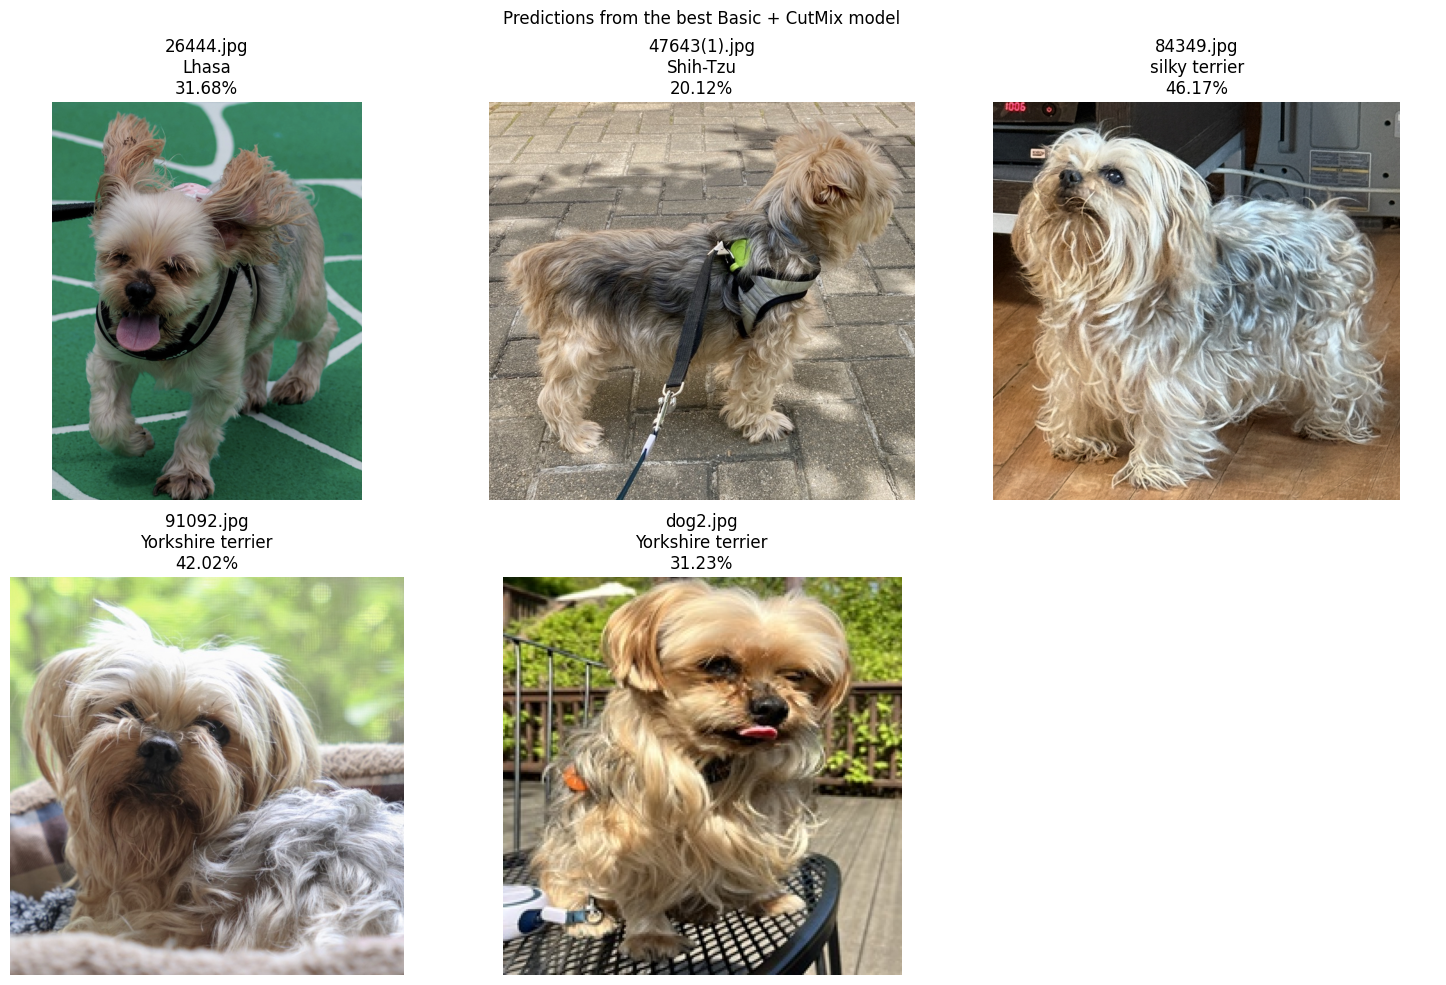

In [8]:
with torch.no_grad():
    logits = best_model(input_batch)
    probabilities = torch.softmax(logits, dim=1)
    top_probabilities, top_indices = probabilities.topk(k=3, dim=1)

top_probabilities = top_probabilities.cpu()
top_indices = top_indices.cpu()


def readable_breed_name(class_name):
    breed_name = class_name.split("-", maxsplit=1)[-1]
    return breed_name.replace("_", " ")


prediction_rows = []
for image_index, image_path in enumerate(image_paths):
    row = {"file": image_path.name}
    for rank in range(3):
        class_index = top_indices[image_index, rank].item()
        probability = top_probabilities[image_index, rank].item()
        row[f"top{rank + 1}_breed"] = readable_breed_name(
            checkpoint["class_names"][class_index]
        )
        row[f"top{rank + 1}_probability"] = 100.0 * probability
    prediction_rows.append(row)

prediction_df = pd.DataFrame(prediction_rows)
display(prediction_df.round(2))
prediction_df.to_csv(
    RESULT_DIR / "my_dog_predictions.csv",
    index=False,
)

num_images = len(image_paths)
num_columns = min(3, num_images)
num_rows = int(np.ceil(num_images / num_columns))
fig, axes = plt.subplots(
    num_rows,
    num_columns,
    figsize=(5 * num_columns, 5 * num_rows),
    squeeze=False,
)

for image_index, (image_path, image) in enumerate(
    zip(image_paths, original_images)
):
    row_index, column_index = divmod(image_index, num_columns)
    ax = axes[row_index, column_index]
    top1_class_index = top_indices[image_index, 0].item()
    top1_name = readable_breed_name(
        checkpoint["class_names"][top1_class_index]
    )
    top1_probability = 100.0 * top_probabilities[image_index, 0].item()

    ax.imshow(image)
    ax.set_title(
        f"{image_path.name}\n"
        f"{top1_name}\n"
        f"{top1_probability:.2f}%"
    )
    ax.axis("off")

for empty_index in range(num_images, num_rows * num_columns):
    row_index, column_index = divmod(empty_index, num_columns)
    axes[row_index, column_index].axis("off")

fig.suptitle("Predictions from the best Basic + CutMix model")
fig.tight_layout()
plt.show()

## 9. 해석 시 주의점

- 이 confidence는 120개 Stanford Dogs 클래스 안에서 계산된 상대 확률입니다.
- 모델이 사진 속 강아지가 학습 클래스 중 하나라고 가정하고 예측하므로,
  믹스견이나 데이터셋에 없는 품종에도 가장 비슷한 견종 이름을 출력합니다.
- best checkpoint는 validation accuracy 기준이며, 기존 실험처럼 모델별 경향을
  비교하기 위한 설정입니다.
- 생성되는 `.pt` 파일에는 이번에는 실제 `model_state_dict`가 포함되므로 기존의
  작은 history `.pt`와 달리 파일 크기가 큽니다.
